In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

from starter_code.data_utils import get_images, get_labels

## Load All Data

In [2]:
disaster = "hurricane-matthew"
data = {}
split = "train"

with open("config.json") as config_file:
    config = json.load(config_file)
    data_dir = config["data_dir"]

print(f"Loading {split} images and labels for {disaster} dataset...")
images = get_images(data_dir, disaster, split=split)
labels = get_labels(data_dir, disaster, split=split)
data[disaster] = {"images": images, "labels": labels}

labels = np.array(labels)

print("Number of images:", len(images))
print("Label distribution:", {
    k: int(v) for k, v in pd.Series(labels).value_counts().sort_index().to_dict().items()
})


Loading train images and labels for hurricane-matthew dataset...
Number of images: 200
Label distribution: {0: 31, 1: 70, 2: 6, 3: 93}


# Multi-Classification: Hurricane vs. Damage Level

## Process Data

In [3]:
images = np.array(images)

images_normalized = images / 255.0
rgb_means = np.mean(images_normalized, axis=(1, 2))

X = rgb_means
Y = labels

print("Feature shape (X):", X.shape)
print("Labels shape (Y):", Y.shape)

Feature shape (X): (200, 3)
Labels shape (Y): (200,)


In [4]:
X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y,test_size=0.2, stratify=Y, random_state=42)

print("Train size:", X_train.shape[0])
print("Valid size:", X_valid.shape[0])

Train size: 160
Valid size: 40


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [6]:
def evaluate_on_validation(name, model, X_valid, Y_valid):
    """
    Print accuracy, weighted F1, classification report, and show confusion matrix for a trained model evaluated on the validation set.
    """
    valid_preds = model.predict(X_valid)

    acc = accuracy_score(Y_valid, valid_preds)
    f1 = f1_score(Y_valid, valid_preds, average="weighted")

    print(f"{name} - Validation Performance")
    print("Accuracy:", acc)
    print("Weighted F1:", f1)
    print("Classification Report:")
    print(classification_report(Y_valid, valid_preds))

    cm = confusion_matrix(Y_valid, valid_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix (Validation)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return acc, f1

## Logistic Regression Model

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/Users/yunuskazimli/Desktop/msse/data200s/Disaster-Visualization/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/yunuskazimli/Desktop/msse/data200s/Disaster-Visualization/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/yunuskazimli/Desktop/msse/data200s/Disaster-Visualization/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid

Best params (LogReg): {'C': 0.1}
Best CV Weighted F1: 0.2790781901995188
Logistic Regression - Validation Performance
Accuracy: 0.2
Weighted F1: 0.14674922600619195
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.35      0.50      0.41        14
           2       0.06      1.00      0.11         1
           3       0.00      0.00      0.00        19

    accuracy                           0.20        40
   macro avg       0.10      0.38      0.13        40
weighted avg       0.12      0.20      0.15        40



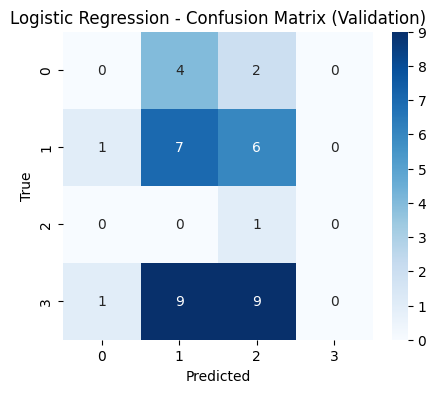

In [7]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, multi_class="multinomial", class_weight="balanced", solver="lbfgs", random_state=42)

log_reg_param_grid = {"C": [0.01, 0.1, 1, 10]}

log_reg_grid = GridSearchCV(estimator=log_reg, param_grid=log_reg_param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1, verbose=1)

log_reg_grid.fit(X_train, Y_train)

print("Best params (LogReg):", log_reg_grid.best_params_)
print("Best CV Weighted F1:", log_reg_grid.best_score_)

best_log_reg = log_reg_grid.best_estimator_
logreg_val_acc, logreg_val_f1 = evaluate_on_validation("Logistic Regression", best_log_reg, X_valid, Y_valid)

## Support Vector Machine

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV macro F1: 0.4317829484112378
SVM (RBF) - Validation Performance
Accuracy: 0.425
Weighted F1: 0.4875
Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         6
           1       0.60      0.43      0.50        14
           2       0.00      0.00      0.00         1
           3       0.62      0.42      0.50        19

    accuracy                           0.42        40
   macro avg       0.43      0.34      0.38        40
weighted avg       0.58      0.42      0.49        40



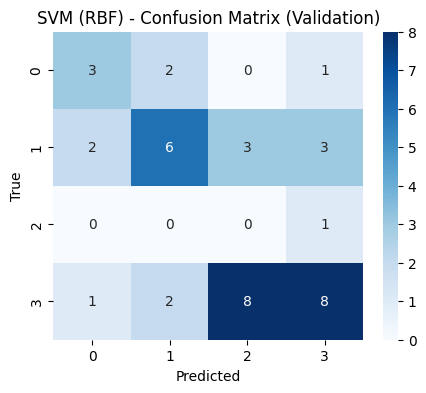

In [8]:
from sklearn.svm import SVC

svm = SVC(class_weight="balanced")

svm_param_grid = {"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.001], "kernel": ["rbf"]}

svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=svm_param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train, Y_train)

print("Best params:", svm_grid.best_params_)
print("Best CV macro F1:", svm_grid.best_score_)

best_svm = svm_grid.best_estimator_
svm_val_acc, svm_val_f1 = evaluate_on_validation("SVM (RBF)", best_svm, X_valid, Y_valid)

## Boosted Trees

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params (GB): {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}
Best CV Weighted F1 (GB): 0.4554247644900829
Gradient Boosting - Validation Performance
Accuracy: 0.5
Weighted F1: 0.4277626811594203
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.33      0.21      0.26        14
           2       0.00      0.00      0.00         1
           3       0.59      0.89      0.71        19

    accuracy                           0.50        40
   macro avg       0.23      0.28      0.24        40
weighted avg       0.40      0.50      0.43        40



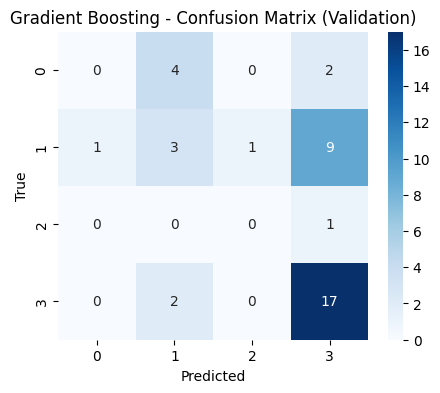

In [9]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb_param_grid = {"n_estimators": [50, 100, 200],"learning_rate": [0.05, 0.1, 0.2],"max_depth": [2, 3, 5]}

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, Y_train)

print("Best params (GB):", gb_grid.best_params_)
print("Best CV Weighted F1 (GB):", gb_grid.best_score_)

best_gb = gb_grid.best_estimator_
gb_val_acc, gb_val_f1 = evaluate_on_validation(
    "Gradient Boosting",
    best_gb,
    X_valid,
    Y_valid
)

In [10]:
results = {
    "Logistic Regression": {
        "cv_f1_weighted": log_reg_grid.best_score_,
        "val_accuracy": logreg_val_acc,
        "val_f1_weighted": logreg_val_f1,
    },
    "SVM (RBF)": {
        "cv_f1_weighted": svm_grid.best_score_,
        "val_accuracy": svm_val_acc,
        "val_f1_weighted": svm_val_f1,
    },
    "Gradient Boosting": {
        "cv_f1_weighted": gb_grid.best_score_,
        "val_accuracy": gb_val_acc,
        "val_f1_weighted": gb_val_f1,
    },
}

print("Model Comparison : Hurricane vs Damage Level")
for model_name, scores in results.items():
    print(f"\n{model_name}:")
    for k, v in scores.items():
        print(f"  {k}: {v}")

Model Comparison : Hurricane vs Damage Level

Logistic Regression:
  cv_f1_weighted: 0.2790781901995188
  val_accuracy: 0.2
  val_f1_weighted: 0.14674922600619195

SVM (RBF):
  cv_f1_weighted: 0.4317829484112378
  val_accuracy: 0.425
  val_f1_weighted: 0.4875

Gradient Boosting:
  cv_f1_weighted: 0.4554247644900829
  val_accuracy: 0.5
  val_f1_weighted: 0.4277626811594203
